Text(0, 0.5, 'Effectiveness')

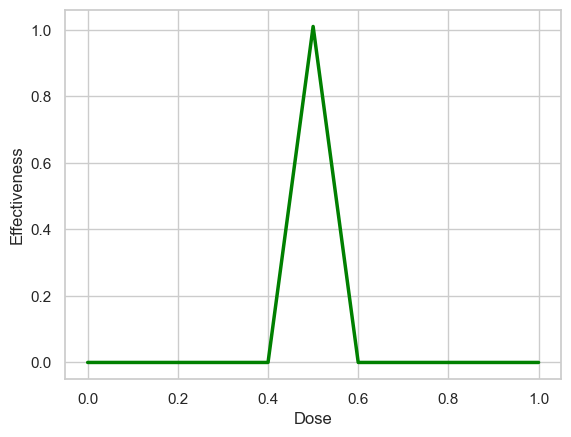

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import matplotlib.pyplot as plt
import seaborn as sns

class BasicNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)
        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(-16.), requires_grad=False)

    def forward(self, input):
        input_to_top_relu = input*self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output*self.w01

        input_to_bottom_relu = input*self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output*self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

input_doses = torch.linspace(start=0, end=1, steps=11)

model = BasicNN()

output_values = model(input_doses)

sns.set(style="whitegrid")
sns.lineplot(x=input_doses,
             y=output_values,
             color='green',
             linewidth=2.5)

plt.xlabel('Dose')
plt.ylabel('Effectiveness')
        

Text(0, 0.5, 'Effectiveness')

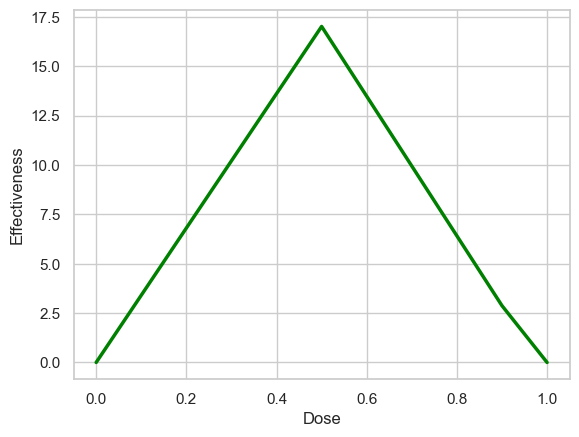

In [10]:
class BasicNN_train(nn.Module):
    def __init__(self):
        super().__init__()

        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad=False)
        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad=False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad=False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def forward(self, input):
        input_to_top_relu = input*self.w00 + self.b00
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output*self.w01

        input_to_bottom_relu = input*self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output*self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

        output = F.relu(input_to_final_relu)

        return output

input_doses = torch.linspace(start=0, end=1, steps=11)

model = BasicNN_train()

output_values = model(input_doses)

sns.set(style="whitegrid")
sns.lineplot(x=input_doses,
             y=output_values.detach(),
             color='green',
             linewidth=2.5)

plt.xlabel('Dose')
plt.ylabel('Effectiveness')
        

In [11]:
inputs = torch.tensor([0., 0.5, 1.0])
labels = torch.tensor([0.0, 1.0, 0.0])

optimizer = SGD(model.parameters(), lr=0.1)
print("Final bias, before optimization: " + str(model.final_bias.data) +"\n")
for epoch in range(100):
    total_loss = 0
    for iteration in range(len(inputs)):

        input_i = inputs[iteration]
        label_i = inputs[iteration]

        output_i = model(input_i)

        loss = (output_i - label_i)**2
        loss.backward()
        total_loss += float(loss)

    if (total_loss < 0.0001):
        print("Num steps: " + str(epoch))
        break

    optimizer.step()
    optimizer.zero_grad()

    print("step: " + str(epoch) + " Final Bias: " + str(model.final_bias.data) + "\n")

print("Final bias, after optimization: " + str(model.final_bias.data))

Final bias, before optimization: tensor(0.)

step: 0 Final Bias: tensor(-3.3020)

step: 1 Final Bias: tensor(-5.9436)

step: 2 Final Bias: tensor(-8.0569)

step: 3 Final Bias: tensor(-9.7475)

step: 4 Final Bias: tensor(-11.1000)

step: 5 Final Bias: tensor(-12.1820)

step: 6 Final Bias: tensor(-13.0476)

step: 7 Final Bias: tensor(-13.7401)

step: 8 Final Bias: tensor(-14.2941)

step: 9 Final Bias: tensor(-14.7373)

step: 10 Final Bias: tensor(-15.0918)

step: 11 Final Bias: tensor(-15.3754)

step: 12 Final Bias: tensor(-15.6024)

step: 13 Final Bias: tensor(-15.7839)

step: 14 Final Bias: tensor(-15.9291)

step: 15 Final Bias: tensor(-16.0453)

step: 16 Final Bias: tensor(-16.1382)

step: 17 Final Bias: tensor(-16.2126)

step: 18 Final Bias: tensor(-16.2721)

step: 19 Final Bias: tensor(-16.3197)

step: 20 Final Bias: tensor(-16.3577)

step: 21 Final Bias: tensor(-16.3882)

step: 22 Final Bias: tensor(-16.4125)

step: 23 Final Bias: tensor(-16.4320)

step: 24 Final Bias: tensor(-16.4

C:\Users\DELL\AppData\Local\Temp\ipykernel_18240\679850673.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  total_loss += float(loss)


step: 39 Final Bias: tensor(-16.5078)

step: 40 Final Bias: tensor(-16.5082)

step: 41 Final Bias: tensor(-16.5086)

step: 42 Final Bias: tensor(-16.5089)

step: 43 Final Bias: tensor(-16.5091)

step: 44 Final Bias: tensor(-16.5093)

step: 45 Final Bias: tensor(-16.5094)

step: 46 Final Bias: tensor(-16.5095)

step: 47 Final Bias: tensor(-16.5096)

step: 48 Final Bias: tensor(-16.5097)

step: 49 Final Bias: tensor(-16.5098)

step: 50 Final Bias: tensor(-16.5098)

step: 51 Final Bias: tensor(-16.5098)

step: 52 Final Bias: tensor(-16.5099)

step: 53 Final Bias: tensor(-16.5099)

step: 54 Final Bias: tensor(-16.5099)

step: 55 Final Bias: tensor(-16.5099)

step: 56 Final Bias: tensor(-16.5100)

step: 57 Final Bias: tensor(-16.5100)

step: 58 Final Bias: tensor(-16.5100)

step: 59 Final Bias: tensor(-16.5100)

step: 60 Final Bias: tensor(-16.5100)

step: 61 Final Bias: tensor(-16.5100)

step: 62 Final Bias: tensor(-16.5100)

step: 63 Final Bias: tensor(-16.5100)

step: 64 Final Bias: tens

In [14]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

X_train = torch.tensor([[1.0], [2.0], [3.0],
                         [4.0], [5.0], [6.0],
                         [7.0], [8.0]])
y_train = torch.tensor([[2.0], [4.0], [6.0],
                         [8.0], [10.0], [12.0],
                         [14.0], [16.0]])

model_simple = nn.Linear(1, 1)
print(f"Initial weight: {model_simple.weight.data}")
print(f"Initial bias:   {model_simple.bias.data}")
print("(random — model knows nothing yet)")


Initial weight: tensor([[-0.7457]])
Initial bias:   tensor([0.4622])
(random — model knows nothing yet)


Epoch   0 | Loss: 181.0388 | Weight: 0.6130 | Bias: 0.7001
Epoch  40 | Loss: 0.1269 | Weight: 1.8609 | Bias: 0.7820
Epoch  80 | Loss: 0.0922 | Weight: 1.8815 | Bias: 0.6664
Epoch 120 | Loss: 0.0669 | Weight: 1.8990 | Bias: 0.5678
Epoch 160 | Loss: 0.0486 | Weight: 1.9139 | Bias: 0.4839

Final weight: 1.9264 (target: 2.0)
Final bias:   0.4140  (target: 0.0)
Model learned y = 2x from data!


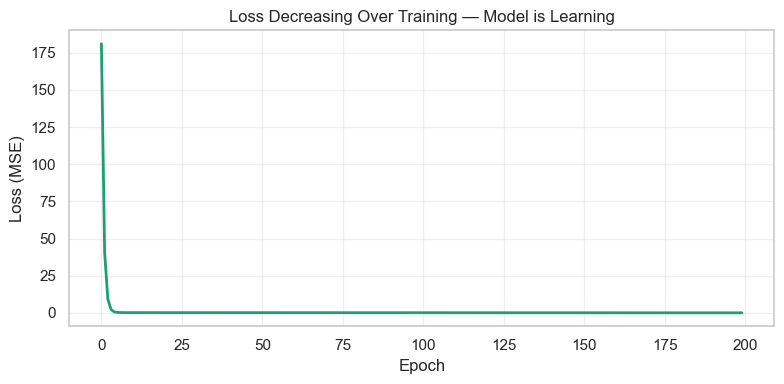

In [17]:
criterion = nn.MSELoss()

optimizer = optim.SGD(model_simple.parameters(), lr=0.01)

losses = []
for epoch in range(200):
    predictions = model_simple(X_train)
    loss = criterion(predictions, y_train)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | "
              f"Weight: {model_simple.weight.data[0][0]:.4f} | "
              f"Bias: {model_simple.bias.data[0]:.4f}")

print(f"\nFinal weight: {model_simple.weight.data[0][0]:.4f} (target: 2.0)")
print(f"Final bias:   {model_simple.bias.data[0]:.4f}  (target: 0.0)")
print("Model learned y = 2x from data!")

plt.figure(figsize=(8, 4))
plt.plot(losses, color='#1D9E75', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss Decreasing Over Training — Model is Learning')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

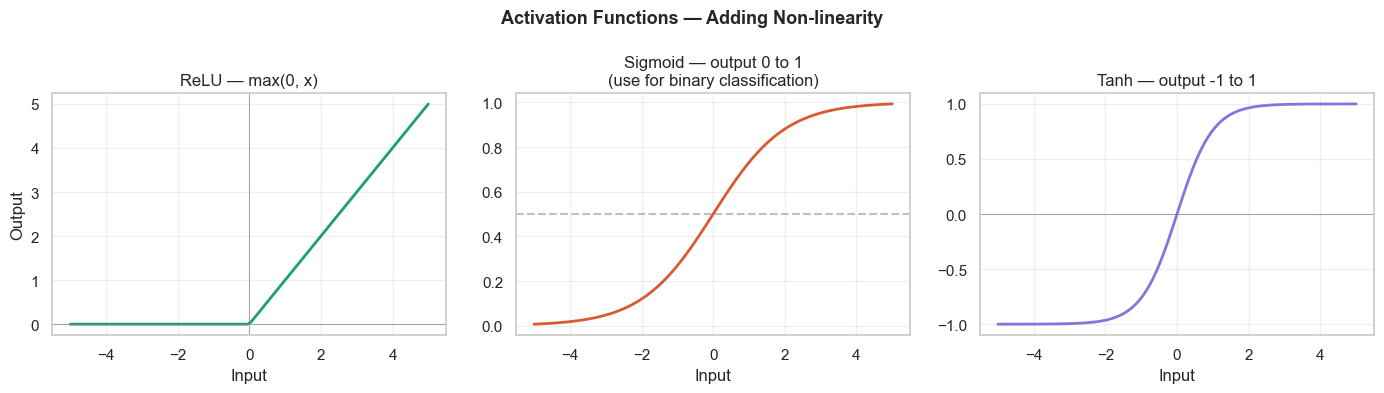

In [18]:
x_vals = torch.linspace(-5, 5, 100)

relu    = nn.ReLU()
sigmoid = nn.Sigmoid()
tanh    = nn.Tanh()

relu_out    = relu(x_vals)
sigmoid_out = sigmoid(x_vals)
tanh_out    = tanh(x_vals)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(x_vals.numpy(), relu_out.numpy(),
             color='#1D9E75', linewidth=2)
axes[0].set_title('ReLU — max(0, x)')
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[1].plot(x_vals.numpy(), sigmoid_out.detach().numpy(),
             color='#D85A30', linewidth=2)
axes[1].set_title('Sigmoid — output 0 to 1\n(use for binary classification)')
axes[1].set_xlabel('Input')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

axes[2].plot(x_vals.numpy(), tanh_out.detach().numpy(),
             color='#7F77DD', linewidth=2)
axes[2].set_title('Tanh — output -1 to 1')
axes[2].set_xlabel('Input')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='gray', linewidth=0.5)

plt.suptitle('Activation Functions — Adding Non-linearity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 300

data_arr = np.column_stack([
    np.concatenate([np.random.normal(88, 6,  100),
                    np.random.normal(65, 8,  100),
                    np.random.normal(38, 10, 100)]),   # attendance
    np.concatenate([np.random.normal(8.2, 0.5, 100),
                    np.random.normal(6.5, 0.7, 100),
                    np.random.normal(4.8, 0.8, 100)]), # cgpa
    np.concatenate([np.random.normal(9.0, 0.8, 100),
                    np.random.normal(6.5, 1.2, 100),
                    np.random.normal(3.5, 1.5, 100)]), # assignments
    np.concatenate([np.random.normal(0.2, 0.4, 100),
                    np.random.normal(1.8, 0.8, 100),
                    np.random.normal(4.5, 1.2, 100)]), # backlogs
    np.concatenate([np.random.normal(8.5, 1.0, 100),
                    np.random.normal(5.5, 1.2, 100),
                    np.random.normal(2.5, 1.0, 100)]), # participation
])

data_arr[:, 0] = data_arr[:, 0].clip(0, 100)  # attendance
data_arr[:, 1] = data_arr[:, 1].clip(0, 10)   # cgpa
data_arr[:, 2] = data_arr[:, 2].clip(0, 10)   # assignments
data_arr[:, 3] = data_arr[:, 3].clip(0, 10)   # backlogs
data_arr[:, 4] = data_arr[:, 4].clip(0, 10)   # participation

labels = (data_arr[:, 1] < 6.0).astype(float)  # cgpa < 6 = at risk

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(data_arr)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_tr)
X_test_t  = torch.FloatTensor(X_te)
y_train_t = torch.FloatTensor(y_tr).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_te).unsqueeze(1)

print(f"Training samples: {len(X_train_t)}")
print(f"Test samples:     {len(X_test_t)}")
print(f"Input features:   5")
print(f"Output:           1 (dropout probability)")


Training samples: 240
Test samples:     60
Input features:   5
Output:           1 (dropout probability)


In [21]:
class StudentDropoutNet(nn.Module):
    """
    Neural network to predict student dropout risk.

    Architecture:
    Input (5) -> Layer1 (16) -> Layer2 (8) -> Output (1)
    Each layer:
    - Linear: weighted sum of inputs + bias
    - ReLU: activation function (adds non-linearity)
    - Dropout: randomly turns off neurons during training
               prevents overfitting
    """
    def __init__(self):
        super(StudentDropoutNet, self).__init__()
        # Layer 1: 5 inputs → 16 neurons
        self.layer1 = nn.Linear(5, 16)

        # Layer 2: 16 neurons → 8 neurons
        self.layer2 = nn.Linear(16, 8)

        # Output layer: 8 neurons → 1 output
        self.output = nn.Linear(8, 1)

        # Activation function
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(p=0.2)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Input → Layer 1 → ReLU → Dropout
        x = self.relu(self.layer1(x))
        x = self.dropout(x)

        # Layer 1 → Layer 2 → ReLU → Dropout
        x = self.relu(self.layer2(x))
        x = self.dropout(x)

        # Layer 2 → Output → Sigmoid (0-1)
        x = self.sigmoid(self.output(x))

        return x

model_nn = StudentDropoutNet()
print("\nNeural Network Architecture:")
print(model_nn)

# Count parameters
total_params = sum(p.numel() for p in model_nn.parameters())
print(f"\nTotal trainable parameters: {total_params}")


Neural Network Architecture:
StudentDropoutNet(
  (layer1): Linear(in_features=5, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)

Total trainable parameters: 241


In [22]:
criterion_nn = nn.BCELoss()

optimizer_nn = optim.Adam(model_nn.parameters(), lr=0.001)

EPOCHS     = 100
train_losses = []
test_losses  = []

for epoch in range(EPOCHS):

    # ── Training mode ──
    model_nn.train()   # enables dropout

    # Forward pass
    train_preds = model_nn(X_train_t)
    train_loss  = criterion_nn(train_preds, y_train_t)

    # Backward pass
    optimizer_nn.zero_grad()
    train_loss.backward()
    optimizer_nn.step()

    model_nn.eval()    # disables dropout
    with torch.no_grad():   # don't track gradients
        test_preds = model_nn(X_test_t)
        test_loss  = criterion_nn(test_preds, y_test_t)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Test Loss: {test_loss.item():.4f}")

print("\nTraining complete!")

Epoch   0 | Train Loss: 0.7043 | Test Loss: 0.6918
Epoch  20 | Train Loss: 0.6658 | Test Loss: 0.6534
Epoch  40 | Train Loss: 0.6267 | Test Loss: 0.6064
Epoch  60 | Train Loss: 0.5685 | Test Loss: 0.5448
Epoch  80 | Train Loss: 0.4981 | Test Loss: 0.4666

Training complete!



Neural Network Accuracy: 90.0%
Correct predictions: 54/60


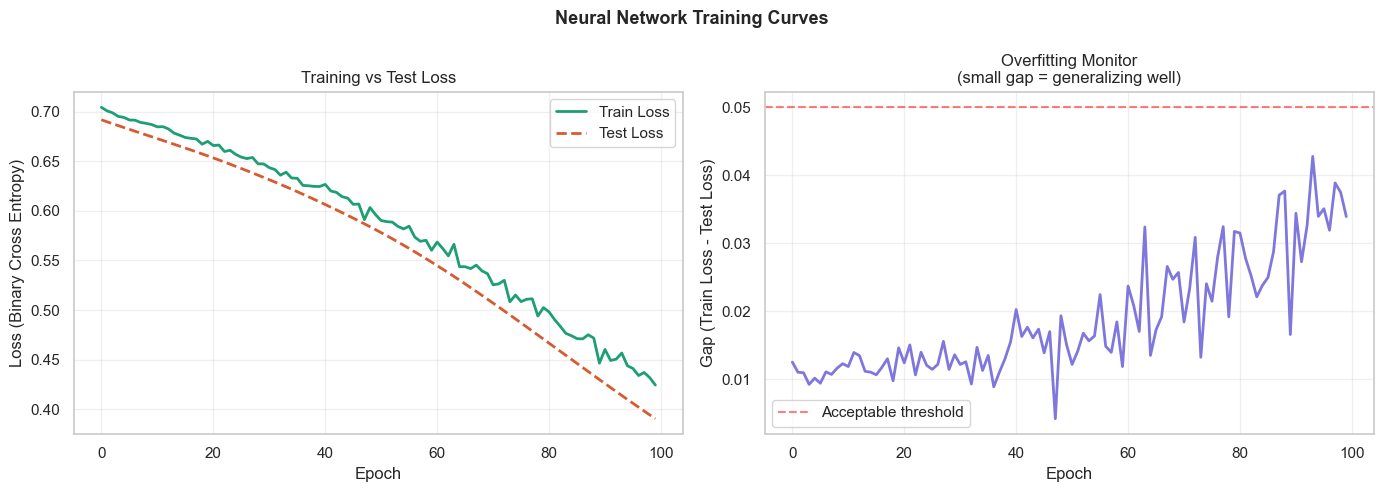

In [23]:
model_nn.eval()
with torch.no_grad():
    test_probs  = model_nn(X_test_t)
    test_labels = (test_probs > 0.5).float()

correct  = (test_labels == y_test_t).sum().item()
total    = len(y_test_t)
accuracy = correct / total * 100

print(f"\nNeural Network Accuracy: {accuracy:.1f}%")
print(f"Correct predictions: {correct}/{total}")

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color='#1D9E75',
         linewidth=2, label='Train Loss')
ax1.plot(test_losses,  color='#D85A30',
         linewidth=2, label='Test Loss',  linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Binary Cross Entropy)')
ax1.set_title('Training vs Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

gap = [abs(t - v) for t, v in zip(train_losses, test_losses)]
ax2.plot(gap, color='#7F77DD', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gap (Train Loss - Test Loss)')
ax2.set_title('Overfitting Monitor\n(small gap = generalizing well)')
ax2.grid(True, alpha=0.3)
ax2.axhline(0.05, color='red', linestyle='--',
            alpha=0.5, label='Acceptable threshold')
ax2.legend()

plt.suptitle('Neural Network Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_compare = RandomForestClassifier(
    n_estimators=100, max_depth=4, random_state=42)
rf_compare.fit(X_tr, y_tr)
rf_acc = accuracy_score(y_te, rf_compare.predict(X_te)) * 100

print("\n" + "=" * 45)
print("MODEL COMPARISON")
print("=" * 45)
print(f"Random Forest accuracy:   {rf_acc:.1f}%")
print(f"Neural Network accuracy:  {accuracy:.1f}%")
print("""
With small datasets (<1000 samples):
  Random Forest usually wins
  Simpler, less data needed, less tuning

With large datasets (>10,000 samples):
  Neural Networks usually win
  Can learn more complex patterns
  But needs more data to generalize
""")



MODEL COMPARISON
Random Forest accuracy:   100.0%
Neural Network accuracy:  90.0%

With small datasets (<1000 samples):
  Random Forest usually wins
  Simpler, less data needed, less tuning

With large datasets (>10,000 samples):
  Neural Networks usually win
  Can learn more complex patterns
  But needs more data to generalize



In [ ]:
def predict_student_nn(attendance, cgpa, assignments,
                       backlogs, participation):
    model_nn.eval()

    # Scale the input the same way training data was scaled
    raw     = np.array([[attendance, cgpa, assignments,
                         backlogs, participation]])
    scaled  = scaler.transform(raw)
    tensor  = torch.FloatTensor(scaled)

    with torch.no_grad():
        prob = model_nn(tensor).item()

    risk = " DROPOUT RISK" if prob > 0.5 else " SAFE"

    print(f"Attendance: {attendance}% | CGPA: {cgpa} | "
          f"Assignments: {assignments}/10")
    print(f"Backlogs: {backlogs} | Participation: {participation}/10")
    print(f"Dropout probability: {prob*100:.1f}%")
    print(f"Status: {risk}")
    print("-" * 45)
    
